In [263]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import convolve

Define the function to compute the kernel given the weights and the degree of the polynomial

In [264]:
def compute_LPA_kernel(w, N):
    # compute the LPA kernel for a given weights and polynomial degree
    # input:
    #   w: vector containing the weights for the local LS problem
    #   N: degree of the polynomial approximation
    # return:
    #   g: the computed LPA kernel

    M = len(w)

    t = np.linspace(0, 1, M)
    T = np.array([t**i for i in range(N + 1)]).T

    W = np.diag(w)

    winv = np.zeros_like(w, dtype=float)
    np.divide(1.0, w, out=winv, where=(w != 0))
    Winv = np.diag(winv)

    Q, _ = np.linalg.qr(W @ T, mode='reduced')

    Qtilde = Winv @ Q
    W2Qtilde = np.diag(w**2) @ Qtilde

    central_row = M // 2

    # compute kernel
    g = np.zeros(M)
    for i in range(N + 1):
        g += Qtilde[central_row, i] * W2Qtilde[:, i]

    g = np.flip(g)

    return g

LPA-ICI
-------
Set the LPA-ICI parameters

In [265]:
# maximum degree of polynomial used for fitting
N = 5

# parameter for the confidence intervals in the ICI rule
Gamma = 2

# Set all the scale values
hmax = 51
all_h = np.arange(int(np.ceil(N / 2)), hmax + 1)

Generate the signal

Text(0.5, 1.0, 'Input Signal')

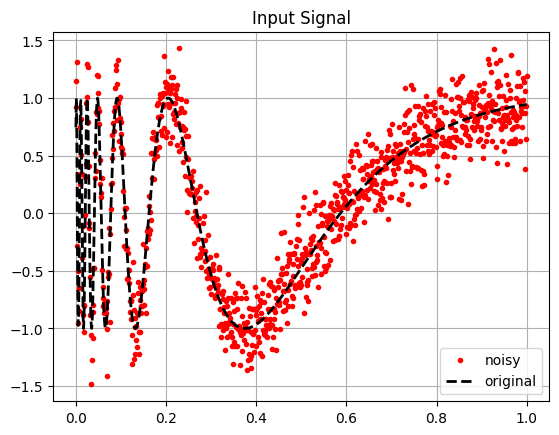

In [266]:
LENGTH = 1000

ty = np.linspace(0, 1, LENGTH)
y = np.sin(2 / (ty + 0.05))

# noise standard deviation
sigma = 0.2

# noisy signal
s = y + sigma * np.random.normal(size=LENGTH)

plt.figure()
plt.plot(ty, s, 'r.')
plt.plot(ty, y, 'k--', linewidth=2)
plt.grid()
plt.legend(['noisy', 'original'])
plt.title('Input Signal')

Generate the LPA kernels for all the scale. Use centered weights.


In [267]:
all_g = []

for i in range(len(all_h)):
    # define the weights for the scale h (symmetric, left or right)
    w = np.ones(2*all_h[i] + 1)
    
    # compute and store the kernel g
    all_g.append( compute_LPA_kernel(w, N))

Initialize all the variables for the ICI rule

In [ ]:
# initialize the estimate
yhat = np.zeros_like(s, dtype=float)

# initialize the vector containing the best scale for each sample
best_scale = np.zeros_like(s, dtype=int)

# initialize the lower and upper bound vectors
lower_bounds = -np.inf * np.ones_like(s)
upper_bounds = np.inf * np.ones_like(s)

yhat_old = None

Loop over all the scales

In [269]:
for i, h in enumerate(all_h):
    g = all_g[i]

    # compute the estimate for the scale h
    yhat_h = convolve(s, g, mode='same')

    std_h = sigma * np.linalg.norm(g, ord=2)
    
    # compute the lower and upper bound of the confidence interval for the scale h
    lb = yhat_h - Gamma * std_h
    ub = yhat_h + Gamma * std_h

    # update the lower and upper bounds
    lower_bounds = np.maximum(lower_bounds, lb)
    upper_bounds = np.minimum(upper_bounds, ub)

    # identify for which samples h is the best scale according to the ICI rule and update the best_scale vector accordingly
    for k in range(len(s)):
        if upper_bounds[k] < lower_bounds[k] and best_scale[k] == 0:
            # if the intersection fails at the first scale, there is no previous estimate available
            if i == 0:
                best_scale[k] = all_h[0]
                yhat[k] = yhat_h[k]
            # the current scale is too large, so we select the previous one as the best scale and we keep the previous estimate
            else:
                # select the previous scale as the best scale
                best_scale[k] = all_h[i - 1]
                # keep the previous estimate
                yhat[k] = yhat_old[k]
    yhat_old = yhat_h

Use the best scale for each sample to compute the final estimates



In [ ]:
yhat_final = yhat.copy()

# recompute the estimate for the largest scale
yhat_h = convolve(s, all_g[-1], mode='same')
# update the estimate for the samples for which the ICI rule never failed
for i in range(len(s)):
    # samples for which the ICI rule never failed have best_scale equal to 0
    if best_scale[i] == 0:
        # use the largest scale as the best scale
        best_scale[i] = all_h[-1]
        # update the estimate for the samples for which the ICI rule fails
        yhat_final[i] = yhat_h[i]

C:\Users\nicco\AppData\Local\Temp\ipykernel_6120\3677056126.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "m-" (-> color='m'). The keyword argument will take precedence.
  ax[0].plot(ty, yhat_final, 'm-', linewidth=3, color = 'blue')


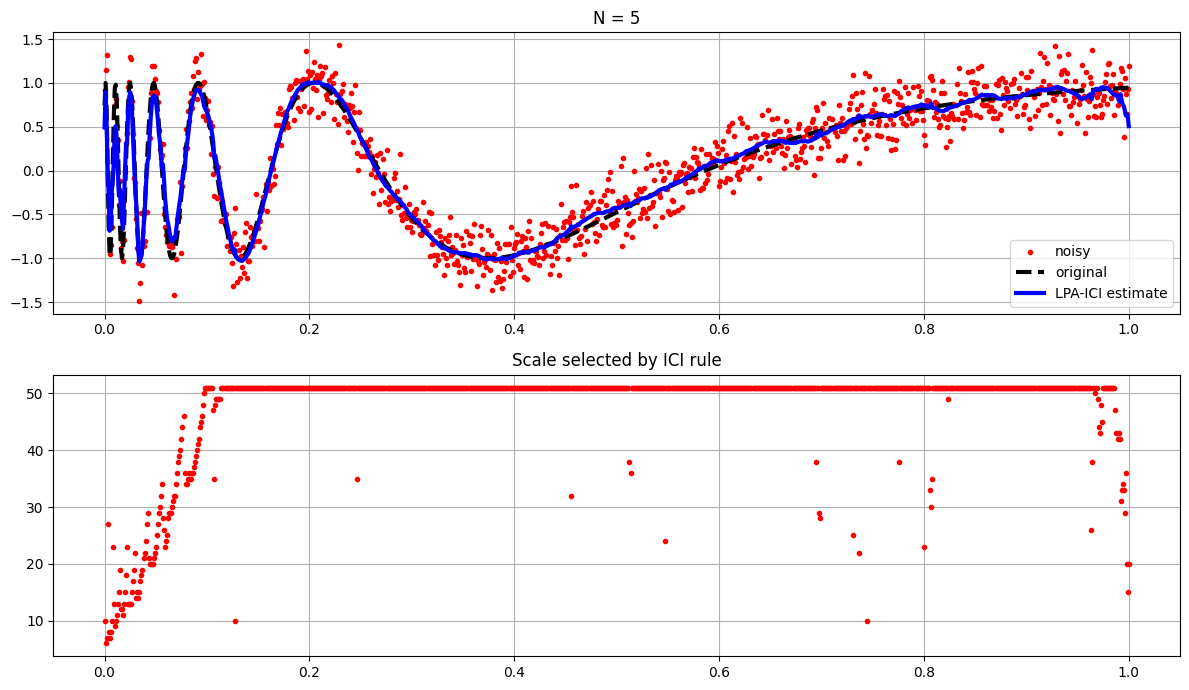

In [ ]:
fig, ax = plt.subplots(2, 1, figsize = (12,7))
ax[0].plot(ty, s, 'r.')
ax[0].plot(ty, y, 'k--', linewidth=3)
ax[0].plot(ty, yhat_final, '-', linewidth=3, color = 'blue')
ax[0].grid()
ax[0].legend(['noisy', 'original', 'LPA-ICI estimate'])
ax[0].set_title(f'N = {N:d}')

ax[1].plot(ty, best_scale, 'r.')
ax[1].set_title('Scale selected by ICI rule')
ax[1].grid()

fig.tight_layout()
plt.show()

LPA-ICI with Aggregation
------------------------
Set the parameters


In [272]:
# maximum degree of polynomial used for fitting
N = 1

# parameter for the confidence intervals in the ICI rule
Gamma = 2

# set all the scale values
hmax = 51
all_h = np.arange(int(np.ceil(N / 2)), hmax + 1)


Generate synthetic signal signal

Text(0.5, 1.0, 'Input Signal')

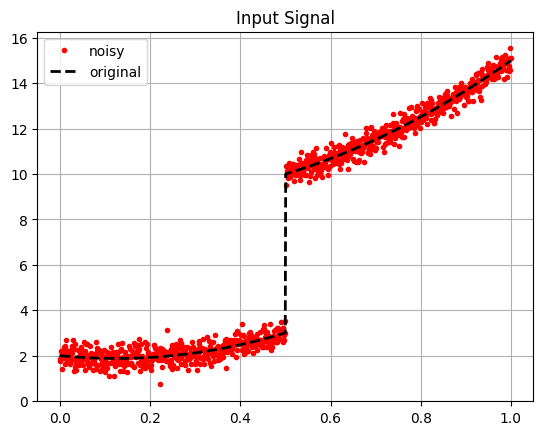

In [273]:
LENGTH = 1000

ty = np.linspace(0, 1, LENGTH)
y = 8 * ty ** 2 - 2*ty + 2
y[ty >0.5] = y[ty >0.5] + 7

# noise standard deviation
sigma = 0.3

# noisy signal
s = y + sigma*np.random.normal(size=LENGTH)

plt.figure()
plt.plot(ty, s, 'r.')
plt.plot(ty, y, 'k--', linewidth=2)
plt.grid()
plt.legend(['noisy', 'original'])
plt.title('Input Signal')

Generate the LPA kernels for all the scale for both left and right windows

In [274]:
all_g_left = []
all_g_right = []

for i, h in enumerate(all_h):
    M = 2*h + 1
    
    # define the weights for the scale h (left)
    w_left = np.zeros(M)
    w_left[:h+1] = 1
    all_g_left.append(compute_LPA_kernel(w_left, N))

    # define the weights for the scale h (right)
    w_right = np.zeros(M)
    w_right[h:] = 1
    all_g_right.append(compute_LPA_kernel(w_right, N))

Use the LPA-ICI to compute the estimate based on the **left** kernels

In [ ]:
# initialize the left estimate
yhat_left = np.zeros_like(s, dtype=float)

# initialize the lower and upper bound vectors
lower_bounds = -np.inf * np.ones_like(s)
upper_bounds = np.inf * np.ones_like(s)

# initialize the vector containing the best scale for each sample
best_scale_left = np.zeros_like(s, dtype=int)

# initialize the vector containing the variance of the estimator for each sample
var_left = np.zeros_like(s, dtype=float)

yhat_old = None

for i, h in enumerate(all_h):
    g = all_g_left[i]

    # compute the estimate for the scale h
    yhat_h = convolve(s, g, mode='same')

    std_h = sigma * np.linalg.norm(g, ord=2)

    # compute the lower and upper bound of the confidence interval for the scale h
    lb = yhat_h - Gamma * std_h
    ub = yhat_h + Gamma * std_h

    # update the lower and upper bounds
    lower_bounds = np.maximum(lower_bounds, lb)
    upper_bounds = np.minimum(upper_bounds, ub)

    # identify for which samples h is the best scale according to the ICI rule
    for k in range(len(s)):
        if upper_bounds[k] < lower_bounds[k] and best_scale_left[k] == 0:
            # if the intersection fails at the first scale, there is no previous estimate available
            if i == 0:
                best_scale_left[k] = all_h[0]
                yhat_left[k] = yhat_h[k]
            # the current scale is too large, so select the previous scale and keep the previous estimate
            else:
                best_scale_left[k] = all_h[i - 1]
                yhat_left[k] = yhat_old[k]

    yhat_old = yhat_h

# start from estimates already selected when ICI failed
yhat_final_left = yhat_left.copy()

# recompute the estimate for the largest scale
yhat_h = convolve(s, all_g_left[-1], mode='same')

# update samples for which the ICI rule never failed
for i in range(len(s)):
    if best_scale_left[i] == 0:
        best_scale_left[i] = all_h[-1]
        yhat_final_left[i] = yhat_h[i]

    idx = np.where(all_h == best_scale_left[i])[0][0]
    var_left[i] = sigma**2 * np.linalg.norm(all_g_left[idx], ord=2)**2

Use the LPA-ICI to compute the estimate based on the **right** kernels

In [ ]:
# initialize the right estimate
yhat_right = np.zeros_like(s, dtype=float)

# initialize the lower and upper bound vectors
lower_bounds = -np.inf * np.ones_like(s)
upper_bounds = np.inf * np.ones_like(s)

# initialize the vector containing the best scale for each sample
best_scale_right = np.zeros_like(s, dtype=int)

# initialize the vector containing the variance of the estimator for each sample
var_right = np.zeros_like(s, dtype=float)

yhat_old = None

for i, h in enumerate(all_h):
    g = all_g_right[i]

    # compute the estimate for the scale h
    yhat_h = convolve(s, g, mode='same')

    std_h = sigma * np.linalg.norm(g, ord=2)

    # compute the lower and upper bound of the confidence interval for the scale h
    lb = yhat_h - Gamma * std_h
    ub = yhat_h + Gamma * std_h

    # update the lower and upper bounds
    lower_bounds = np.maximum(lower_bounds, lb)
    upper_bounds = np.minimum(upper_bounds, ub)

    # identify for which samples h is the best scale according to the ICI rule
    for k in range(len(s)):
        if upper_bounds[k] < lower_bounds[k] and best_scale_right[k] == 0:
            # if the intersection fails at the first scale, there is no previous estimate available
            if i == 0:
                best_scale_right[k] = all_h[0]
                yhat_right[k] = yhat_h[k]
            # the current scale is too large, so select the previous scale and keep the previous estimate
            else:
                best_scale_right[k] = all_h[i - 1]
                yhat_right[k] = yhat_old[k]

    yhat_old = yhat_h

# start from estimates already selected when ICI failed
yhat_final_right = yhat_right.copy()

# recompute the estimate for the largest scale
yhat_h = convolve(s, all_g_right[-1], mode='same')

# update samples for which the ICI rule never failed
for i in range(len(s)):
    if best_scale_right[i] == 0:
        best_scale_right[i] = all_h[-1]
        yhat_final_right[i] = yhat_h[i]

    idx = np.where(all_h == best_scale_right[i])[0][0]
    var_right[i] = sigma**2 * np.linalg.norm(all_g_right[idx], ord=2)**2

Perform the aggregation


In [277]:
eps = 1e-12

w_left = 1 / (var_left + eps)
w_right = 1 / (var_right + eps)

yhat_aggr = (w_left * yhat_final_left + w_right * yhat_final_right) / (w_left + w_right)

Text(0.5, 1.0, 'N = 1')

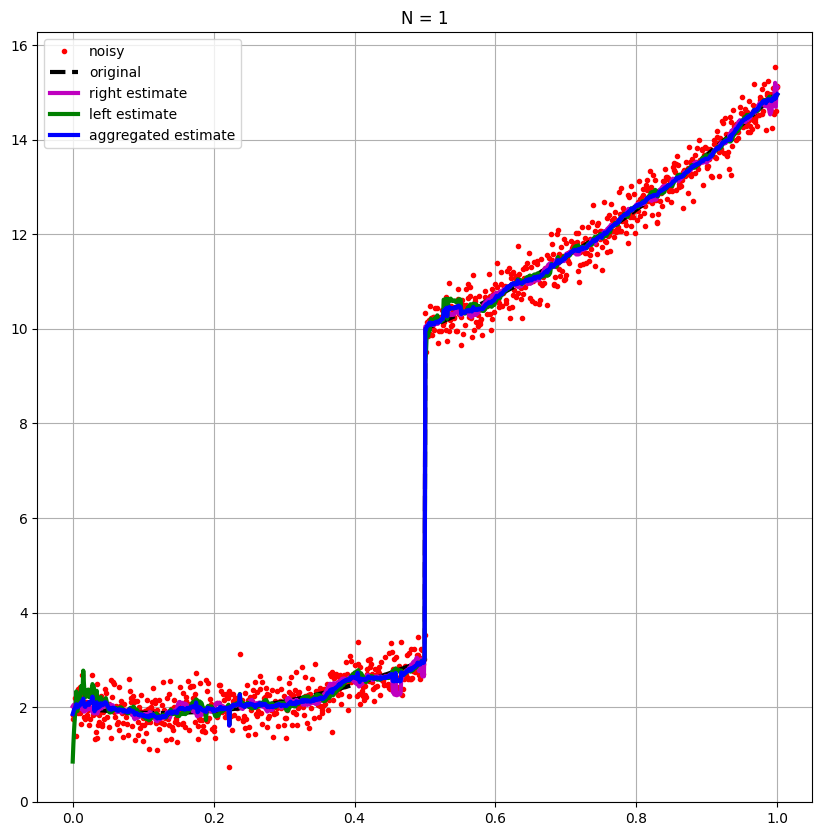

In [278]:
plt.figure(figsize=(10,10))
plt.plot(ty, s, 'r.')
plt.plot(ty, y, 'k--', linewidth=3)
plt.plot(ty, yhat_final_right, 'm-', linewidth=3)
plt.plot(ty, yhat_final_left, 'g-', linewidth=3)
plt.plot(ty, yhat_aggr, 'b-', linewidth=3)
plt.grid()
plt.legend(['noisy', 'original', 'right estimate', 'left estimate', 'aggregated estimate'])
plt.title(f'N = {N:d}')